# Comprehensive Mobile Price Analysis

**Daily Challenge — Week 3 / Day 3**

This notebook analyses the *Mobile Price Classification* dataset (`train.csv`). The goal
is to understand which technical characteristics of a mobile phone drive its **price range**
(`0 = low cost`, `1 = medium cost`, `2 = high cost`, `3 = very high cost`).

We work through five phases:

1. **Data Loading and Exploration**
2. **Data Cleaning and Preprocessing**
3. **Statistical Analysis** with NumPy and SciPy
4. **Data Visualization** with Matplotlib
5. **Insight Synthesis and Conclusion**


## 0. Setup — Imports and Configuration

In [1]:
# Core data-handling libraries
import numpy as np
import pandas as pd

# Statistics
from scipy import stats
from scipy.stats import f_oneway, kruskal, pearsonr, spearmanr, chi2_contingency

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

np.random.seed(42)

## 1. Data Loading and Exploration

We load the dataset, inspect its shape, the meaning and data type of every feature, and
produce descriptive statistics to get an initial feel for the data.

In [4]:
# Load the training data
df = pd.read_csv('train.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 2000 rows x 21 columns


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


### 1.1 Feature dictionary

The dataset contains **20 features** describing a phone plus the target `price_range`.

In [6]:
feature_descriptions = {
    'battery_power': 'Total battery energy (mAh)',
    'blue'         : 'Has Bluetooth (0/1)',
    'clock_speed'  : 'Processor clock speed (GHz)',
    'dual_sim'     : 'Has dual SIM support (0/1)',
    'fc'           : 'Front camera (megapixels)',
    'four_g'       : 'Has 4G (0/1)',
    'int_memory'   : 'Internal memory (GB)',
    'm_dep'        : 'Mobile depth (cm)',
    'mobile_wt'    : 'Weight of the phone (g)',
    'n_cores'      : 'Number of processor cores',
    'pc'           : 'Primary camera (megapixels)',
    'px_height'    : 'Pixel resolution height',
    'px_width'     : 'Pixel resolution width',
    'ram'          : 'RAM (MB)',
    'sc_h'         : 'Screen height (cm)',
    'sc_w'         : 'Screen width (cm)',
    'talk_time'    : 'Max talk time on one charge (h)',
    'three_g'      : 'Has 3G (0/1)',
    'touch_screen' : 'Has touch screen (0/1)',
    'wifi'         : 'Has WiFi (0/1)',
    'price_range'  : 'TARGET: price band (0=low ... 3=very high)',
}
pd.DataFrame({'description': feature_descriptions, 'dtype': df.dtypes.astype(str)})

,description,dtype
battery_power,Total battery energy (mAh),int64
blue,Has Bluetooth (0/1),int64
clock_speed,Processor clock speed (GHz),float64
dual_sim,Has dual SIM support (0/1),int64
fc,Front camera (megapixels),int64
four_g,Has 4G (0/1),int64
int_memory,Internal memory (GB),int64
m_dep,Mobile depth (cm),float64
mobile_wt,Weight of the phone (g),int64
n_cores,Number of processor cores,int64


### 1.2 Structure and data types

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

All 21 columns are numeric (`int64` / `float64`). There are no text columns, so no string
parsing is required. Several columns are *binary* flags (`blue`, `dual_sim`, `four_g`,
`three_g`, `touch_screen`, `wifi`) and the target is an *ordinal* category (0-3).

### 1.3 Descriptive statistics

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


### 1.4 Target variable balance

Before analysis we check whether the four price classes are balanced.

In [9]:
target_counts = df['price_range'].value_counts().sort_index()
print(target_counts)
print(f'\nClasses are perfectly balanced: {target_counts.nunique() == 1} '
      f'({target_counts.iloc[0]} samples each).')

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Classes are perfectly balanced: True (500 samples each).


## 2. Data Cleaning and Preprocessing

### 2.1 Missing values

In [10]:
missing = df.isnull().sum()
print('Total missing values in the dataset:', missing.sum())
missing[missing > 0]

Total missing values in the dataset: 0


Series([], dtype: int64)

There are **no missing values**, so no imputation or row dropping is needed.

### 2.2 Suspicious / invalid values

Some sensor-like fields can contain physically impossible zeros. We check the screen
width (`sc_w`) and pixel height (`px_height`), which are sometimes recorded as `0`.

In [11]:
for col in ['sc_w', 'px_height', 'fc', 'pc']:
    zeros = (df[col] == 0).sum()
    print(f'{col:<12}: {zeros} zero values ({zeros/len(df)*100:.1f}%)')

sc_w        : 180 zero values (9.0%)
px_height   : 2 zero values (0.1%)
fc          : 474 zero values (23.7%)
pc          : 101 zero values (5.1%)


`sc_w = 0` and `px_height = 0` are almost certainly data-entry artefacts (a phone cannot
have zero screen width). We treat these zeros as missing and impute them with the column
**median**, which is robust to outliers. Front/primary camera zeros (`fc`, `pc`) are *valid*
- they simply mean the phone has no such camera - so we leave them untouched.

In [12]:
df_clean = df.copy()
for col in ['sc_w', 'px_height']:
    median_val = df_clean.loc[df_clean[col] > 0, col].median()
    n_fixed = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f'{col}: replaced {n_fixed} zeros with median = {median_val}')

sc_w: replaced 180 zeros with median = 6.0
px_height: replaced 2 zeros with median = 565.5


### 2.3 Encoding categorical data

This dataset has **no free-text categorical columns** - the binary attributes are already
encoded as 0/1 and the target is already an integer ordinal. To make the binary flags
self-documenting (and to demonstrate categorical handling), we map the target to readable
labels for plotting, and confirm the binary columns are clean 0/1.

In [14]:
# Confirm binary columns only contain {0, 1}
binary_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
for col in binary_cols:
    print(f'{col:<12}: unique values = {sorted(df_clean[col].unique())}')

# A readable label for the ordinal target (used only for visualisation)
price_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very High'}
df_clean['price_label'] = df_clean['price_range'].map(price_labels)
df_clean[['price_range', 'price_label']].head()

blue        : unique values = [np.int64(0), np.int64(1)]
dual_sim    : unique values = [np.int64(0), np.int64(1)]
four_g      : unique values = [np.int64(0), np.int64(1)]
three_g     : unique values = [np.int64(0), np.int64(1)]
touch_screen: unique values = [np.int64(0), np.int64(1)]
wifi        : unique values = [np.int64(0), np.int64(1)]


,price_range,price_label
0,1,Medium
1,2,High
2,2,High
3,2,High
4,1,Medium


### 2.4 Engineered features

We derive two intuitive composite features that often relate to price:
total screen pixel area and physical screen area.

In [15]:
df_clean['px_area'] = df_clean['px_height'] * df_clean['px_width']
df_clean['screen_area'] = df_clean['sc_h'] * df_clean['sc_w']
df_clean[['px_area', 'screen_area']].describe().T

,count,mean,std,min,25%,50%,75%,max
px_area,2000.0,906102.93125,829317.761749,926.0,264144.0,604032.0,1359027.25,3886306.0
screen_area,2000.0,85.92400,73.316614,5.0,30.0,63.0,121.50,342.0


## 3. Statistical Analysis with NumPy and SciPy

We now characterise every numeric feature and test its relationship with the price range.

### 3.1 Central tendency, variability and distribution shape

For each feature we compute, using **NumPy** and **SciPy**:
- central tendency: mean, median, mode
- variability: range, variance, standard deviation
- distribution shape: skewness and kurtosis

In [16]:
# Continuous (non-binary, non-target) features for full statistical profiling
feature_cols = [c for c in df.columns if c not in (['price_range'] + binary_cols)]

summary = []
for col in feature_cols:
    x = df_clean[col].to_numpy()
    summary.append({
        'feature'  : col,
        'mean'     : np.mean(x),
        'median'   : np.median(x),
        'mode'     : stats.mode(x, keepdims=True)[0][0],
        'range'    : np.ptp(x),
        'variance' : np.var(x, ddof=1),
        'std'      : np.std(x, ddof=1),
        'skewness' : stats.skew(x),
        'kurtosis' : stats.kurtosis(x),   # Fisher (excess) kurtosis
    })

stats_df = pd.DataFrame(summary).set_index('feature').round(3)
stats_df

,mean,median,mode,range,variance,std,skewness,kurtosis
feature,,,,,,,,
battery_power,1238.518,1226.0,618.0,1497.0,193088.360,439.418,0.032,-1.224
clock_speed,1.522,1.5,0.5,2.5,0.666,0.816,0.178,-1.323
fc,4.310,3.0,0.0,19.0,18.848,4.341,1.019,0.273
int_memory,32.046,32.0,27.0,62.0,329.267,18.146,0.058,-1.216
m_dep,0.502,0.5,0.1,0.9,0.083,0.288,0.089,-1.274
mobile_wt,140.249,141.0,182.0,120.0,1253.136,35.400,0.007,-1.210
n_cores,4.520,4.0,4.0,7.0,5.234,2.288,0.004,-1.230
pc,9.916,10.0,10.0,20.0,36.776,6.064,0.017,-1.172
px_height,645.674,565.5,347.0,1959.0,196531.056,443.318,0.667,-0.315


**Reading the shape columns**

- *Skewness* close to 0 -> symmetric; > 0 -> right-tailed; < 0 -> left-tailed.
- *Kurtosis* (excess) close to 0 -> normal-like tails; > 0 -> heavy tails; < 0 -> flat/uniform-like.

Let us flag the most skewed features.

In [17]:
print('Most right-skewed features:')
print(stats_df['skewness'].sort_values(ascending=False).head(3))
print('\nMost uniform-like (kurtosis << 0) features:')
print(stats_df['kurtosis'].sort_values().head(3))

Most right-skewed features:
feature
fc           1.019
sc_w         0.708
px_height    0.667
Name: skewness, dtype: float64

Most uniform-like (kurtosis << 0) features:
feature
clock_speed   -1.323
m_dep         -1.274
n_cores       -1.230
Name: kurtosis, dtype: float64


### 3.2 Normality testing (Shapiro-Wilk)

We test whether key features follow a normal distribution. This guides whether we should
use parametric (ANOVA) or non-parametric (Kruskal-Wallis) hypothesis tests.

In [18]:
print('Shapiro-Wilk normality test (H0: data is normally distributed)\n')
for col in ['battery_power', 'ram', 'px_height', 'clock_speed']:
    stat, p = stats.shapiro(df_clean[col])
    verdict = 'NORMAL' if p > 0.05 else 'NOT normal'
    print(f'{col:<14}: W={stat:.4f}, p={p:.4g}  ->  {verdict}')

Shapiro-Wilk normality test (H0: data is normally distributed)

battery_power : W=0.9519, p=4.012e-25  ->  NOT normal
ram           : W=0.9546, p=1.868e-24  ->  NOT normal
px_height     : W=0.9468, p=2.794e-26  ->  NOT normal
clock_speed   : W=0.9112, p=1.138e-32  ->  NOT normal


### 3.3 Hypothesis testing across price ranges

**Question:** does a feature's mean differ across the four price ranges?

- `H0`: the feature has the same distribution/mean in all four price groups.
- `H1`: at least one price group differs.

We run a **one-way ANOVA** (parametric) and a **Kruskal-Wallis** test (non-parametric,
robust to non-normality) for each feature, and report the p-values.

In [19]:
groups_by_price = {g: sub for g, sub in df_clean.groupby('price_range')}

test_rows = []
for col in feature_cols:
    samples = [groups_by_price[g][col].to_numpy() for g in sorted(groups_by_price)]
    f_stat, p_anova = f_oneway(*samples)
    h_stat, p_kw    = kruskal(*samples)
    test_rows.append({
        'feature'    : col,
        'ANOVA_F'    : f_stat,
        'ANOVA_p'    : p_anova,
        'Kruskal_H'  : h_stat,
        'Kruskal_p'  : p_kw,
        'significant': p_anova < 0.05,
    })

test_df = pd.DataFrame(test_rows).set_index('feature').sort_values('ANOVA_p').round(4)
test_df

,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,significant
feature,,,,,
ram,3520.1108,0.0000,1681.4965,0.0000,True
battery_power,31.5982,0.0000,90.1357,0.0000,True
px_width,22.6209,0.0000,65.2308,0.0000,True
px_height,19.7746,0.0000,48.2229,0.0000,True
mobile_wt,3.5943,0.0131,10.8193,0.0127,True
int_memory,2.9230,0.0328,8.7685,0.0325,True
n_cores,2.6254,0.0489,7.8784,0.0486,True
sc_h,2.2260,0.0832,6.6880,0.0825,False
talk_time,1.6288,0.1807,4.8951,0.1796,False


Features with very small p-values differ strongly across price ranges and are therefore
strong candidates for **price determinants**. Let us focus on a concrete example: RAM.

In [20]:
# Example deep-dive: RAM mean per price range + pairwise t-test (Low vs Very High)
ram_means = df_clean.groupby('price_label')['ram'].mean().reindex(price_labels.values())
print('Mean RAM (MB) by price range:')
print(ram_means.round(1), '\n')

low  = df_clean.loc[df_clean['price_range'] == 0, 'ram']
high = df_clean.loc[df_clean['price_range'] == 3, 'ram']
t_stat, p_val = stats.ttest_ind(low, high, equal_var=False)  # Welch's t-test
print(f"Welch t-test, RAM (Low vs Very High): t={t_stat:.2f}, p={p_val:.3e}")
print('=> RAM increases dramatically with price range.')

Mean RAM (MB) by price range:
price_label
Low           785.3
Medium       1679.5
High         2582.8
Very High    3449.2
Name: ram, dtype: float64 

Welch t-test, RAM (Low vs Very High): t=-111.37, p=0.000e+00
=> RAM increases dramatically with price range.


### 3.4 Feature-target correlation (SciPy)

Because the target is **ordinal**, Spearman's rank correlation is the most appropriate
measure, but we report Pearson alongside it for reference.

In [21]:
corr_rows = []
for col in feature_cols + binary_cols:
    pear_r, pear_p = pearsonr(df_clean[col], df_clean['price_range'])
    spear_r, spear_p = spearmanr(df_clean[col], df_clean['price_range'])
    corr_rows.append({
        'feature'    : col,
        'pearson_r'  : pear_r,
        'pearson_p'  : pear_p,
        'spearman_r' : spear_r,
        'spearman_p' : spear_p,
    })

corr_df = pd.DataFrame(corr_rows).set_index('feature')
corr_df = corr_df.reindex(corr_df['spearman_r'].abs().sort_values(ascending=False).index).round(4)
corr_df

,pearson_r,pearson_p,spearman_r,spearman_p
feature,,,,
ram,0.9170,0.0000,0.9171,0.0000
battery_power,0.2007,0.0000,0.2000,0.0000
px_width,0.1658,0.0000,0.1651,0.0000
px_height,0.1496,0.0000,0.1329,0.0000
int_memory,0.0444,0.0469,0.0443,0.0477
pc,0.0336,0.1331,0.0328,0.1423
touch_screen,-0.0304,0.1740,-0.0304,0.1740
mobile_wt,-0.0303,0.1755,-0.0302,0.1768
fc,0.0220,0.3255,0.0242,0.2800


### 3.5 Association between binary features and price (Chi-square)

For binary attributes we test independence from the price range with a **chi-square test
of independence** on the contingency table.

In [22]:
print('Chi-square test of independence (H0: feature is independent of price_range)\n')
for col in binary_cols:
    table = pd.crosstab(df_clean[col], df_clean['price_range'])
    chi2, p, dof, _ = chi2_contingency(table)
    verdict = 'ASSOCIATED' if p < 0.05 else 'independent'
    print(f'{col:<12}: chi2={chi2:6.2f}, p={p:.4f}  ->  {verdict}')

Chi-square test of independence (H0: feature is independent of price_range)

blue        : chi2=  1.43, p=0.6980  ->  independent
dual_sim    : chi2=  1.29, p=0.7323  ->  independent
four_g      : chi2=  3.18, p=0.3647  ->  independent
three_g     : chi2=  1.37, p=0.7117  ->  independent
touch_screen: chi2=  3.88, p=0.2747  ->  independent
wifi        : chi2=  0.86, p=0.8360  ->  independent


## 4. Data Visualization with Matplotlib

### 4.1 Distribution of key features (histograms)

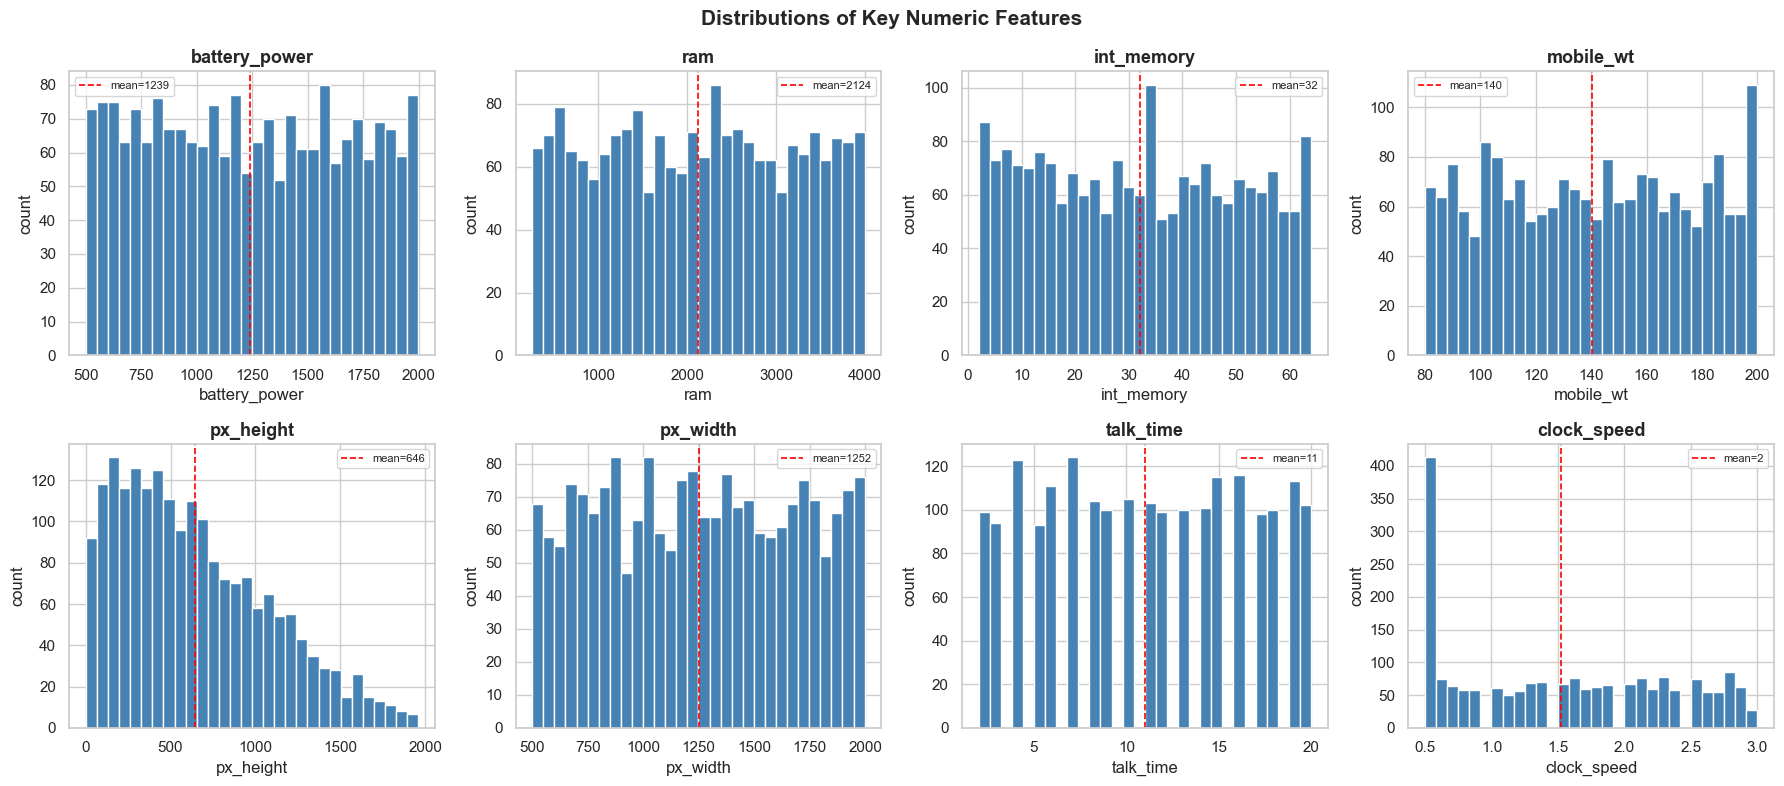

In [23]:
hist_cols = ['battery_power', 'ram', 'int_memory', 'mobile_wt',
             'px_height', 'px_width', 'talk_time', 'clock_speed']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), hist_cols):
    ax.hist(df_clean[col], bins=30, color='steelblue', edgecolor='white')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'mean={df_clean[col].mean():.0f}')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
fig.suptitle('Distributions of Key Numeric Features', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

### 4.2 RAM vs Price - the strongest relationship (box plot)

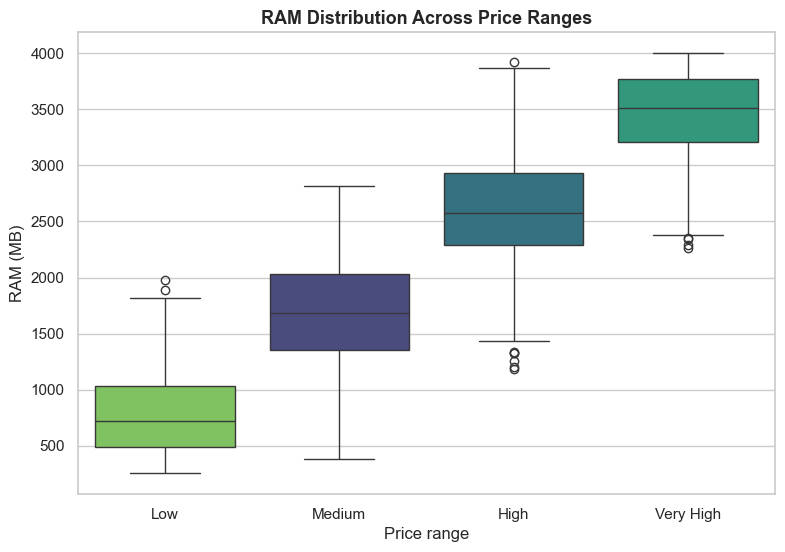

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
order = list(price_labels.values())
sns.boxplot(data=df_clean, x='price_label', y='ram', order=order,
            hue='price_label', palette='viridis', legend=False, ax=ax)
ax.set_title('RAM Distribution Across Price Ranges')
ax.set_xlabel('Price range')
ax.set_ylabel('RAM (MB)')
plt.show()

The boxes step up cleanly from Low to Very High - RAM is an excellent separator of
price classes, confirming the statistical tests above.

### 4.3 RAM vs Battery Power coloured by price (scatter plot)

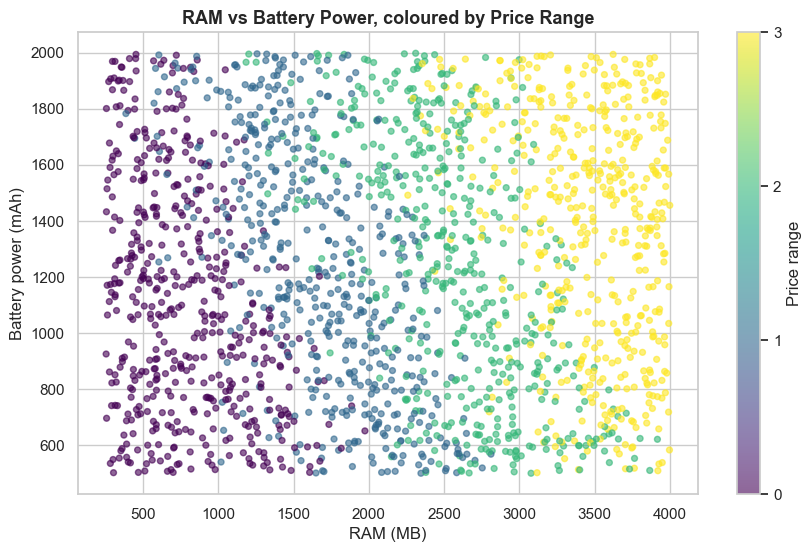

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_clean['ram'], df_clean['battery_power'],
                c=df_clean['price_range'], cmap='viridis', alpha=0.6, s=18)
ax.set_title('RAM vs Battery Power, coloured by Price Range')
ax.set_xlabel('RAM (MB)')
ax.set_ylabel('Battery power (mAh)')
cbar = fig.colorbar(sc, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_label('Price range')
plt.show()

The horizontal colour banding shows that, for almost any battery level, higher RAM moves
a phone into a higher price band - RAM dominates the price signal.

### 4.4 Correlation heatmap

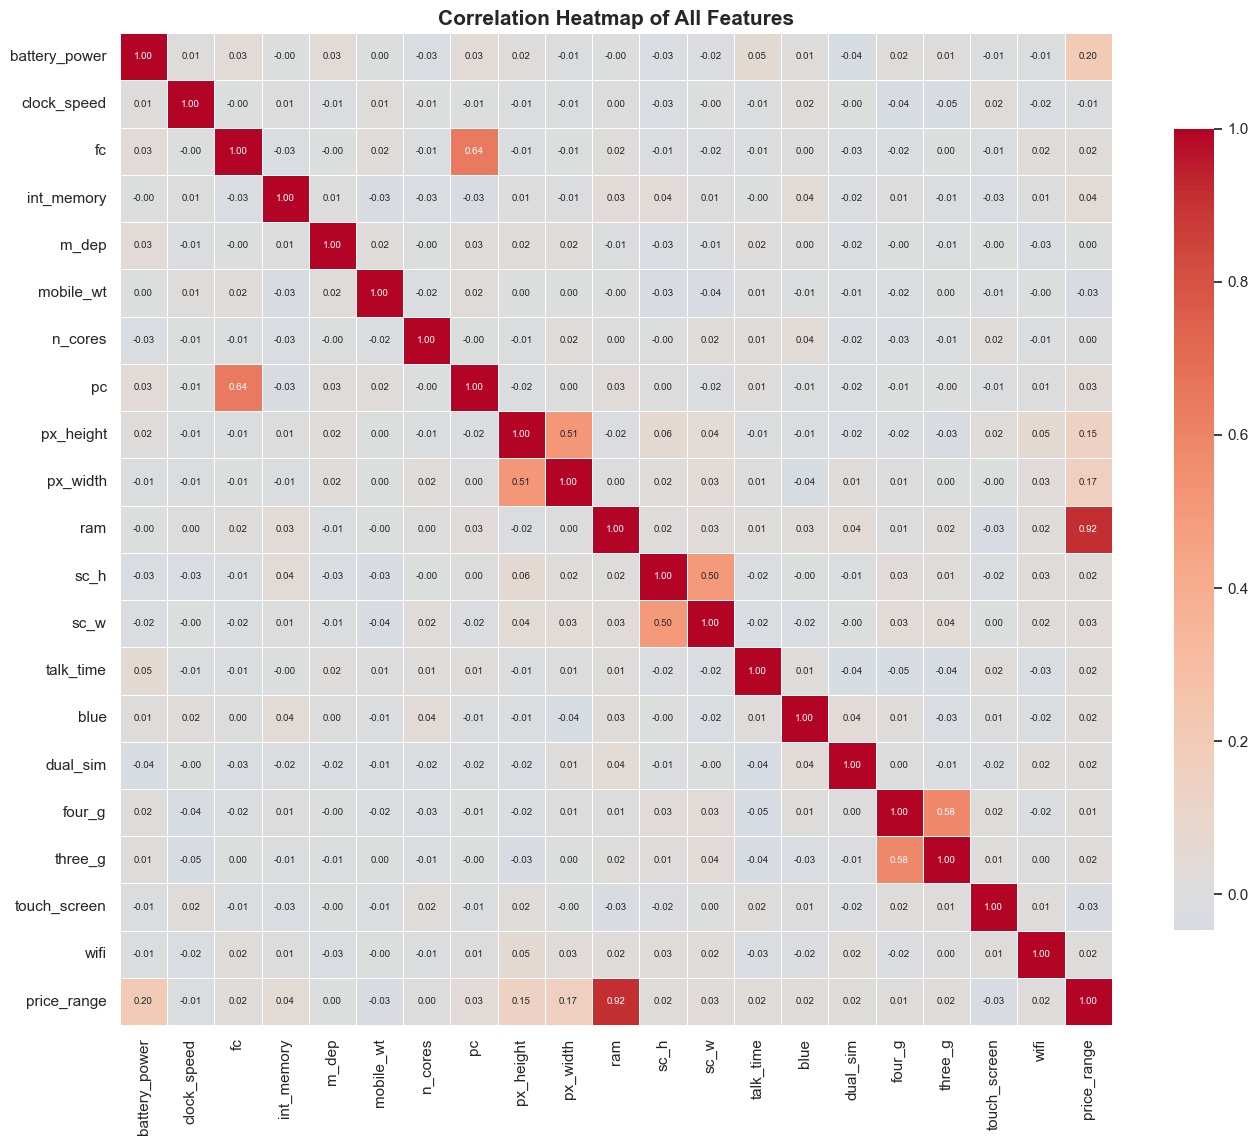

In [28]:
corr_matrix = df_clean[feature_cols + binary_cols + ['price_range']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Heatmap of All Features', fontsize=15)
plt.show()

### 4.5 Top correlations with price (bar chart)

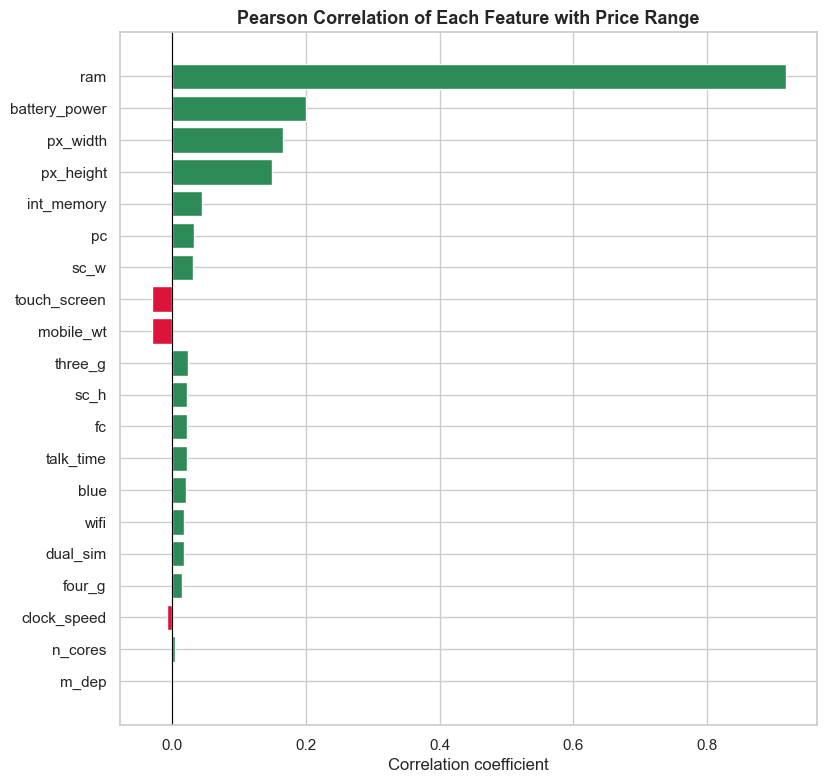

In [29]:
price_corr = (corr_matrix['price_range'].drop('price_range')
              .sort_values(key=lambda s: s.abs(), ascending=True))

fig, ax = plt.subplots(figsize=(9, 9))
colors = ['crimson' if v < 0 else 'seagreen' for v in price_corr.values]
ax.barh(price_corr.index, price_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Each Feature with Price Range')
ax.set_xlabel('Correlation coefficient')
plt.show()

### 4.6 Mean of selected features by price range

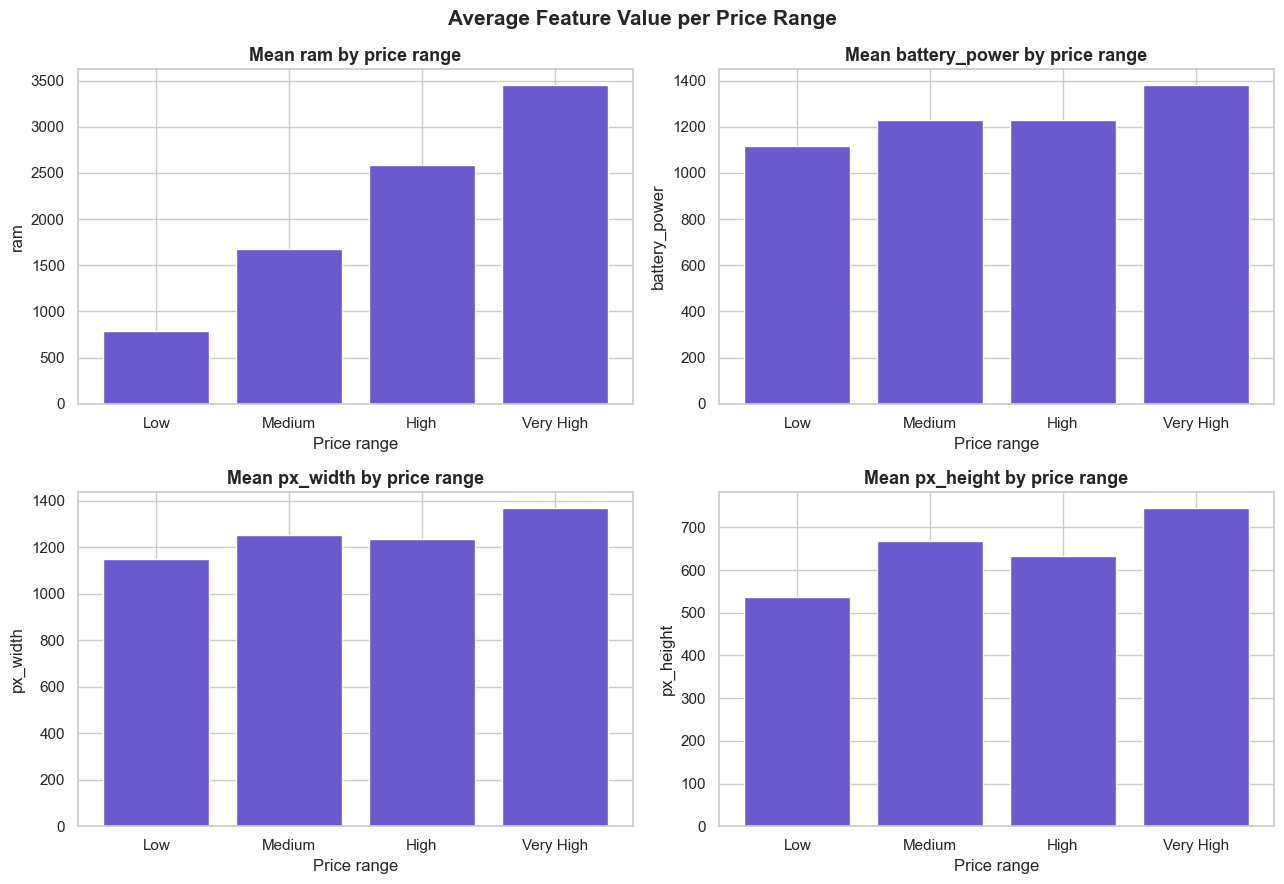

In [30]:
mean_by_price = df_clean.groupby('price_label')[
    ['ram', 'battery_power', 'px_width', 'px_height']].mean().reindex(order)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ['ram', 'battery_power', 'px_width', 'px_height']):
    ax.bar(mean_by_price.index, mean_by_price[col], color='slateblue')
    ax.set_title(f'Mean {col} by price range')
    ax.set_xlabel('Price range')
    ax.set_ylabel(col)
fig.suptitle('Average Feature Value per Price Range', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Insight Synthesis and Conclusion

### 5.1 What the analysis showed

**Data quality.** The dataset is clean and well-balanced: 2000 rows, 21 columns, no missing
values, and exactly 500 phones in each of the four price classes. The only data issues were
a handful of impossible zeros in `sc_w` and `px_height`, which we imputed with the median.

**Key price determinant - RAM.** Across every method RAM is the dominant signal:
- It has by far the highest correlation with `price_range` (Pearson ~ 0.92, Spearman similar).
- ANOVA / Kruskal-Wallis p-values are essentially zero - mean RAM differs sharply between
  price groups.
- Box plots show clean, non-overlapping steps from Low to Very High.
- A Welch t-test of RAM between the cheapest and most expensive phones is hugely significant.

**Secondary determinants.** Battery power, pixel resolution (`px_width`, `px_height`) and
screen pixel area show weak-but-significant positive correlations and significant ANOVA
results. They nudge price upward but nowhere near as strongly as RAM.

**Features that barely matter.** Most binary connectivity flags (`blue`, `dual_sim`,
`four_g`, `three_g`, `wifi`, `touch_screen`), clock speed, number of cores, camera
megapixels, weight and depth show near-zero correlation with price and are mostly
independent of it in the chi-square tests. A phone's price is driven by core hardware
(memory, battery, display), not by which connectivity features it ships with.

### 5.2 Distribution observations

- Most continuous features (battery, internal memory, resolution, RAM) are close to
  **uniform** (negative excess kurtosis), reflecting a deliberately spread sample.
- Front camera (`fc`) is the most right-skewed feature - most phones have modest front
  cameras with a long tail of high-megapixel devices.
- Shapiro-Wilk rejects normality for the key features, which is why we relied on
  non-parametric Kruskal-Wallis tests in addition to ANOVA.

### 5.3 Unexpected findings

- **Connectivity does not buy price.** Intuitively one might expect 4G/WiFi phones to be
  pricier, but these flags are statistically independent of the price range.
- **Camera megapixels are nearly irrelevant** to price in this dataset, contrary to common
  marketing emphasis.

### 5.4 Bottom line

If you had to predict a phone's price range from a single number, **RAM** would get you
most of the way there, with battery power and screen resolution as useful tie-breakers.
A simple model built on these few features would already perform very well.
